# GP Likelihood From Split Force Curves: Dynamic + Quasi-Static

This notebook builds an inverse GP likelihood map using the **piecewise-omega flat-leg simulations**.

Training data:

- 36 coarse soil cases from `data/synthetic_data/cohesion_phi_piecewise_omega_force_sweep`
- inputs: `phi_deg`, `cohesion_kPa`
- output observables: full-force-curve features from both `Fz` and `Fx`

Validation data:

- four midpoint soil cases from `data/synthetic_data/cohesion_phi_piecewise_omega_force_sweep_midpoints`
- midpoint cases are **held out** and are not used to fit the GP

## Dynamic and Quasi-Static Split

The current piecewise actuation is:

- first `1/4` of angular trip: `omega_1 = 15 rad/s`
- remaining `3/4` of angular trip: `omega_2 = 5 rad/s`

The notebook therefore splits each force curve into:

- **dynamic segment:** normalized stroke fraction `0.00 <= s <= 0.25`
- **quasi-static segment:** normalized stroke fraction `0.25 < s <= 1.00`

The split is based on the actual angle in `terradyn_flat.csv`:

```text
s = (90 deg - theta_deg) / 180 deg
```

So, for the `-90 deg` to `+90 deg` sweep stored internally as `+90 -> -90`, the dynamic/quasi-static boundary is approximately `theta_deg = +45 deg`.

## Curve Observables

For each case, this notebook uses more than peak force:

- resampled `Fz` and `Fx` values over the dynamic segment
- resampled `Fz` and `Fx` values over the quasi-static segment
- segment statistics for each force component: mean, standard deviation, peak absolute value, and integral

These observables are combined into one joint Gaussian log-likelihood map:

```text
log L(phi, c | dynamic Fz/Fx curve features AND quasi-static Fz/Fx curve features)
```


In [1]:
from pathlib import Path
import csv
import json

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

TRAIN_ROOT = ROOT / "data" / "synthetic_data" / "cohesion_phi_piecewise_omega_force_sweep"
VAL_ROOT = ROOT / "data" / "synthetic_data" / "cohesion_phi_piecewise_omega_force_sweep_midpoints"
OUT_DIR = ROOT / "data" / "synthetic_data" / "gp_piecewise_curve_split"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DYNAMIC_FRACTION = 0.25
N_DYNAMIC_SAMPLES = 8
N_QUASI_SAMPLES = 16
SMOOTH_WINDOW = 401

# Set SHOW_FIGURES=False before executing this notebook in batch tests.
SHOW_FIGURES = globals().get("SHOW_FIGURES", True)

print(f"Training root:   {TRAIN_ROOT}")
print(f"Validation root: {VAL_ROOT}")
print(f"Output dir:      {OUT_DIR}")


Training root:   /Users/daweixu/Desktop/Git_Repository/project_MPM_robot_soil/data/synthetic_data/cohesion_phi_piecewise_omega_force_sweep
Validation root: /Users/daweixu/Desktop/Git_Repository/project_MPM_robot_soil/data/synthetic_data/cohesion_phi_piecewise_omega_force_sweep_midpoints
Output dir:      /Users/daweixu/Desktop/Git_Repository/project_MPM_robot_soil/data/synthetic_data/gp_piecewise_curve_split


In [2]:
def read_summary(path):
    with path.open() as f:
        return json.load(f)


def read_force_csv(path):
    theta_deg = []
    fz_n = []
    fx_n = []
    with path.open(newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            theta_deg.append(float(row["theta_deg"]))
            fz_n.append(float(row["Fz_mN"]) / 1000.0)
            fx_n.append(float(row["Fx_mN"]) / 1000.0)
    return {
        "theta_deg": np.asarray(theta_deg, dtype=float),
        "Fz_N": np.asarray(fz_n, dtype=float),
        "Fx_N": np.asarray(fx_n, dtype=float),
    }


def moving_average(y, window=401):
    y = np.asarray(y, dtype=float)
    if window <= 1 or len(y) < 3:
        return y.copy()
    window = int(min(window, len(y)))
    if window % 2 == 0:
        window -= 1
    if window < 3:
        return y.copy()
    pad = window // 2
    y_pad = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(window, dtype=float) / window
    return np.convolve(y_pad, kernel, mode="valid")


def parse_case(case_dir, source):
    summary_path = case_dir / "summary.json"
    csv_path = case_dir / "terradyn_flat.csv"
    if not summary_path.exists() or not csv_path.exists():
        return None
    summary = read_summary(summary_path)
    return {
        "source": source,
        "phi_deg": float(summary["phi_deg"]),
        "cohesion_kPa": float(summary["c_Pa"]) / 1000.0,
        "cohesion_Pa": float(summary["c_Pa"]),
        "omega_mode": summary.get("omega_mode", "piecewise"),
        "omega_1_rad_s": summary.get("omega_1_rad_s"),
        "omega_2_rad_s": summary.get("omega_2_rad_s"),
        "omega_1_frac": summary.get("omega_1_frac"),
        "case_dir": str(case_dir),
        "csv_path": str(csv_path),
        "summary_path": str(summary_path),
    }


def discover_cases(root, source):
    rows = []
    for csv_path in sorted(root.glob("**/terradyn_flat.csv")):
        case = parse_case(csv_path.parent, source)
        if case is not None:
            rows.append(case)
    return sorted(rows, key=lambda r: (r["cohesion_kPa"], r["phi_deg"]))

train_cases = discover_cases(TRAIN_ROOT, "coarse_train")
val_cases = discover_cases(VAL_ROOT, "midpoint_validation")

print(f"Training cases discovered:   {len(train_cases)}")
print(f"Validation cases discovered: {len(val_cases)}")

if len(train_cases) != 36:
    print("Warning: expected 36 training cases. Run script/sweep_cohesion_phi_piecewise_omega_forces.py if needed.")
if len(val_cases) != 4:
    print("Warning: expected 4 validation cases. Run script/sweep_midpoint_cohesion_phi_piecewise_omega_forces.sh if needed.")

for row in train_cases[:3]:
    print(row["phi_deg"], row["cohesion_kPa"], row["omega_mode"], row["csv_path"])


Training cases discovered:   36
Validation cases discovered: 4
10.0 0.0 piecewise /Users/daweixu/Desktop/Git_Repository/project_MPM_robot_soil/data/synthetic_data/cohesion_phi_piecewise_omega_force_sweep/c_0kPa/phi_10deg/piecewise_omega1_15_omega2_5/terradyn_flat.csv
14.999999999999998 0.0 piecewise /Users/daweixu/Desktop/Git_Repository/project_MPM_robot_soil/data/synthetic_data/cohesion_phi_piecewise_omega_force_sweep/c_0kPa/phi_15deg/piecewise_omega1_15_omega2_5/terradyn_flat.csv
20.0 0.0 piecewise /Users/daweixu/Desktop/Git_Repository/project_MPM_robot_soil/data/synthetic_data/cohesion_phi_piecewise_omega_force_sweep/c_0kPa/phi_20deg/piecewise_omega1_15_omega2_5/terradyn_flat.csv


In [3]:
def stroke_fraction(theta_deg):
    # Internal CSV convention sweeps from +90 deg to -90 deg.
    return (90.0 - np.asarray(theta_deg, dtype=float)) / 180.0


def interp_at_fraction(s, y, targets):
    order = np.argsort(s)
    s_sorted = np.asarray(s, dtype=float)[order]
    y_sorted = np.asarray(y, dtype=float)[order]
    keep = np.r_[True, np.diff(s_sorted) > 1e-12]
    s_sorted = s_sorted[keep]
    y_sorted = y_sorted[keep]
    return np.interp(targets, s_sorted, y_sorted)


def segment_stats(s, y, lo, hi):
    mask = (s >= lo) & (s <= hi)
    if np.sum(mask) < 2:
        return [np.nan, np.nan, np.nan, np.nan]
    ss = s[mask]
    yy = y[mask]
    return [
        float(np.mean(yy)),
        float(np.std(yy)),
        float(np.max(np.abs(yy))),
        float(np.trapz(yy, ss)),
    ]


def build_curve_features(case):
    curve = read_force_csv(Path(case["csv_path"]))
    s = stroke_fraction(curve["theta_deg"])
    fz = moving_average(curve["Fz_N"], SMOOTH_WINDOW)
    fx = moving_average(curve["Fx_N"], SMOOTH_WINDOW)

    dyn_targets = np.linspace(0.0, DYNAMIC_FRACTION, N_DYNAMIC_SAMPLES)
    quasi_targets = np.linspace(DYNAMIC_FRACTION, 1.0, N_QUASI_SAMPLES)

    features = {}
    for name, y in [("Fz", fz), ("Fx", fx)]:
        dyn_vals = interp_at_fraction(s, y, dyn_targets)
        quasi_vals = interp_at_fraction(s, y, quasi_targets)

        for i, value in enumerate(dyn_vals):
            features[f"dynamic_{name}_sample_{i:02d}"] = float(value)
        for i, value in enumerate(quasi_vals):
            features[f"quasi_{name}_sample_{i:02d}"] = float(value)

        for stat_name, value in zip(
            ["mean", "std", "peak_abs", "integral_s"],
            segment_stats(s, y, 0.0, DYNAMIC_FRACTION),
        ):
            features[f"dynamic_{name}_{stat_name}"] = float(value)

        for stat_name, value in zip(
            ["mean", "std", "peak_abs", "integral_s"],
            segment_stats(s, y, DYNAMIC_FRACTION, 1.0),
        ):
            features[f"quasi_{name}_{stat_name}"] = float(value)
    return features

train_feature_rows = []
for case in train_cases:
    row = dict(case)
    row.update(build_curve_features(case))
    train_feature_rows.append(row)

val_feature_rows = []
for case in val_cases:
    row = dict(case)
    row.update(build_curve_features(case))
    val_feature_rows.append(row)

FEATURE_COLS = sorted([
    key for key in train_feature_rows[0]
    if key.startswith("dynamic_") or key.startswith("quasi_")
]) if train_feature_rows else []

print(f"Number of curve observables: {len(FEATURE_COLS)}")
print("First 10 observables:")
for col in FEATURE_COLS[:10]:
    print(" ", col)


/var/folders/jq/khx6mlw900l3dzqh_x5_9v540000gn/T/ipykernel_54602/911225866.py:26: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  float(np.trapz(yy, ss)),


Number of curve observables: 64
First 10 observables:
  dynamic_Fx_integral_s
  dynamic_Fx_mean
  dynamic_Fx_peak_abs
  dynamic_Fx_sample_00
  dynamic_Fx_sample_01
  dynamic_Fx_sample_02
  dynamic_Fx_sample_03
  dynamic_Fx_sample_04
  dynamic_Fx_sample_05
  dynamic_Fx_sample_06


In [4]:
def write_feature_table(path, rows, feature_cols):
    if not rows:
        return
    base_cols = [
        "source", "phi_deg", "cohesion_kPa", "cohesion_Pa",
        "omega_mode", "omega_1_rad_s", "omega_2_rad_s", "omega_1_frac",
        "case_dir", "csv_path", "summary_path",
    ]
    with path.open("w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=base_cols + feature_cols)
        writer.writeheader()
        for row in rows:
            writer.writerow({col: row.get(col, "") for col in base_cols + feature_cols})

train_table_path = OUT_DIR / "piecewise_curve_split_training_table.csv"
val_table_path = OUT_DIR / "piecewise_curve_split_validation_table.csv"
write_feature_table(train_table_path, train_feature_rows, FEATURE_COLS)
write_feature_table(val_table_path, val_feature_rows, FEATURE_COLS)
print(f"Wrote: {train_table_path}")
print(f"Wrote: {val_table_path}")


Wrote: /Users/daweixu/Desktop/Git_Repository/project_MPM_robot_soil/data/synthetic_data/gp_piecewise_curve_split/piecewise_curve_split_training_table.csv
Wrote: /Users/daweixu/Desktop/Git_Repository/project_MPM_robot_soil/data/synthetic_data/gp_piecewise_curve_split/piecewise_curve_split_validation_table.csv


In [5]:
if not train_feature_rows:
    raise RuntimeError("No training rows found. Run the piecewise 36-case sweep first.")

X_raw = np.array([[r["phi_deg"], r["cohesion_kPa"]] for r in train_feature_rows], dtype=float)
Y_raw = np.array([[r[col] for col in FEATURE_COLS] for r in train_feature_rows], dtype=float)

x_mean = X_raw.mean(axis=0)
x_std = X_raw.std(axis=0)
x_std[x_std == 0.0] = 1.0
X = (X_raw - x_mean) / x_std

y_mean = Y_raw.mean(axis=0)
y_std = Y_raw.std(axis=0)
y_std[y_std == 0.0] = 1.0
Y = (Y_raw - y_mean) / y_std

print("X mean [phi, c_kPa]:", x_mean)
print("X std  [phi, c_kPa]:", x_std)
print("Y shape:", Y.shape)


X mean [phi, c_kPa]: [22.5 12.5]
X std  [phi, c_kPa]: [8.53912564 8.53912564]
Y shape: (36, 64)


In [6]:
def rbf_kernel(A, B, length_scale=0.8, amplitude=1.0):
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    diff = A[:, None, :] - B[None, :, :]
    sqdist = np.sum((diff / length_scale) ** 2, axis=2)
    return amplitude**2 * np.exp(-0.5 * sqdist)


def train_fixed_rbf_gp(X, y, length_scale=0.85, amplitude=1.0, noise=1e-5):
    K = rbf_kernel(X, X, length_scale=length_scale, amplitude=amplitude)
    K = K + (noise**2 + 1e-10) * np.eye(len(X))
    L = np.linalg.cholesky(K)
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y))
    return {
        "X": X.copy(),
        "y": y.copy(),
        "length_scale": float(length_scale),
        "amplitude": float(amplitude),
        "noise": float(noise),
        "L": L,
        "alpha": alpha,
    }


def predict_fixed_rbf_gp(model, X_star):
    X_star = np.atleast_2d(np.asarray(X_star, dtype=float))
    K_star = rbf_kernel(X_star, model["X"], model["length_scale"], model["amplitude"])
    mean = K_star @ model["alpha"]
    v = np.linalg.solve(model["L"], K_star.T)
    prior_var = model["amplitude"] ** 2
    var = np.maximum(prior_var - np.sum(v * v, axis=0), 1e-12)
    return mean, np.sqrt(var)

# Train one independent scalar GP per curve observable.
gps = []
for j, col in enumerate(FEATURE_COLS):
    gps.append(train_fixed_rbf_gp(X, Y[:, j], length_scale=0.85, amplitude=1.0, noise=1e-5))

print(f"Trained {len(gps)} scalar GPs.")


Trained 64 scalar GPs.


In [7]:
def standardize_x(phi_deg, cohesion_kpa):
    return (np.array([[phi_deg, cohesion_kpa]], dtype=float) - x_mean) / x_std


def gp_predict_features(phi_deg, cohesion_kpa, return_std=True):
    x_star = standardize_x(phi_deg, cohesion_kpa)
    pred = {}
    for k, (col, model) in enumerate(zip(FEATURE_COLS, gps)):
        mu_std, sigma_std = predict_fixed_rbf_gp(model, x_star)
        mu = float(mu_std[0] * y_std[k] + y_mean[k])
        sigma = float(sigma_std[0] * y_std[k])
        pred[col] = (mu, sigma) if return_std else mu
    return pred


def gp_log_likelihood(phi_deg, cohesion_kpa, obs_row, obs_noise_std=0.12):
    # Scalar version, useful for checking individual points.
    x_star = standardize_x(phi_deg, cohesion_kpa)
    ll = 0.0
    used = 0
    for k, (col, model) in enumerate(zip(FEATURE_COLS, gps)):
        mu_std, gp_sigma_std = predict_fixed_rbf_gp(model, x_star)
        obs_std = (float(obs_row[col]) - y_mean[k]) / y_std[k]
        total_sigma = np.sqrt(float(gp_sigma_std[0])**2 + obs_noise_std**2)
        resid = obs_std - float(mu_std[0])
        ll += -0.5 * ((resid / total_sigma) ** 2 + np.log(2.0 * np.pi * total_sigma**2))
        used += 1
    return ll / max(used, 1)


LIKELIHOOD_GRID_CACHE = {}


def make_likelihood_grid(obs_row, phi_grid=None, c_grid=None, obs_noise_std=0.12):
    # Vectorized grid evaluation: all grid points at once for each curve observable.
    if phi_grid is None:
        phi_grid = np.linspace(10.0, 35.0, 101)
    if c_grid is None:
        c_grid = np.linspace(0.0, 25.0, 101)

    phi_grid = np.asarray(phi_grid, dtype=float)
    c_grid = np.asarray(c_grid, dtype=float)
    cache_key = (
        obs_row.get("case_dir", f"phi_{obs_row['phi_deg']}_c_{obs_row['cohesion_kPa']}"),
        len(phi_grid), float(phi_grid[0]), float(phi_grid[-1]),
        len(c_grid), float(c_grid[0]), float(c_grid[-1]),
        float(obs_noise_std),
    )
    if cache_key in LIKELIHOOD_GRID_CACHE:
        return LIKELIHOOD_GRID_CACHE[cache_key]

    PHI, C = np.meshgrid(phi_grid, c_grid)
    X_star_raw = np.column_stack([PHI.ravel(), C.ravel()])
    X_star = (X_star_raw - x_mean) / x_std

    ll_vec = np.zeros(X_star.shape[0], dtype=float)
    for k, (col, model) in enumerate(zip(FEATURE_COLS, gps)):
        mu_std, gp_sigma_std = predict_fixed_rbf_gp(model, X_star)
        obs_std = (float(obs_row[col]) - y_mean[k]) / y_std[k]
        total_sigma = np.sqrt(gp_sigma_std**2 + obs_noise_std**2)
        resid = obs_std - mu_std
        ll_vec += -0.5 * ((resid / total_sigma) ** 2 + np.log(2.0 * np.pi * total_sigma**2))

    LL = (ll_vec / max(len(FEATURE_COLS), 1)).reshape(len(c_grid), len(phi_grid))
    best_idx = np.unravel_index(np.argmax(LL), LL.shape)
    best = {
        "phi_deg": float(phi_grid[best_idx[1]]),
        "cohesion_kPa": float(c_grid[best_idx[0]]),
        "log_likelihood_per_feature": float(LL[best_idx]),
    }
    result = (phi_grid, c_grid, LL, best)
    LIKELIHOOD_GRID_CACHE[cache_key] = result
    return result


def relative_likelihood(LL):
    dLL = LL - np.max(LL)
    return np.exp(np.clip(dLL, -80.0, 0.0))


In [8]:
# Quick training-grid sanity check: predict every training point at its own location.
train_errors = []
for row in train_feature_rows:
    pred = gp_predict_features(row["phi_deg"], row["cohesion_kPa"], return_std=False)
    err = []
    for col in FEATURE_COLS:
        scale = max(abs(row[col]), 1e-6)
        err.append(abs(pred[col] - row[col]) / scale)
    train_errors.append({
        "phi_deg": row["phi_deg"],
        "cohesion_kPa": row["cohesion_kPa"],
        "mean_abs_rel_error": float(np.mean(err)),
        "max_abs_rel_error": float(np.max(err)),
    })

print("Training reconstruction check:")
print("  mean of mean relative errors:", np.mean([r["mean_abs_rel_error"] for r in train_errors]))
print("  max of max relative errors:  ", np.max([r["max_abs_rel_error"] for r in train_errors]))


Training reconstruction check:
  mean of mean relative errors: 3.0598580556962267e-09
  max of max relative errors:   1.2292080443998496e-07


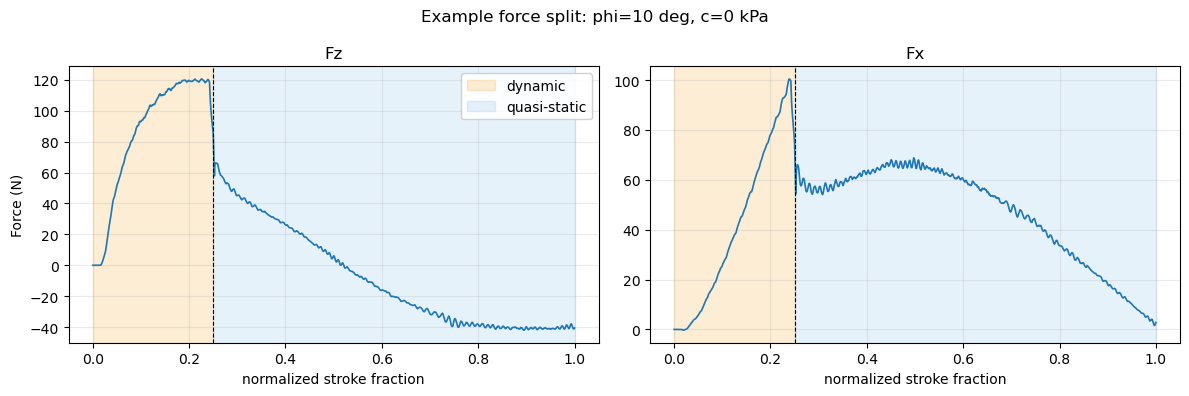

Saved: /Users/daweixu/Desktop/Git_Repository/project_MPM_robot_soil/data/synthetic_data/gp_piecewise_curve_split/example_dynamic_quasi_static_split.png


In [9]:
def plot_force_split_example(row):
    curve = read_force_csv(Path(row["csv_path"]))
    s = stroke_fraction(curve["theta_deg"])
    fz = moving_average(curve["Fz_N"], SMOOTH_WINDOW)
    fx = moving_average(curve["Fx_N"], SMOOTH_WINDOW)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
    for ax, y, name in [(axes[0], fz, "Fz"), (axes[1], fx, "Fx")]:
        ax.plot(s, y, lw=1.2)
        ax.axvspan(0.0, DYNAMIC_FRACTION, color="#F39C12", alpha=0.18, label="dynamic")
        ax.axvspan(DYNAMIC_FRACTION, 1.0, color="#3498DB", alpha=0.12, label="quasi-static")
        ax.axvline(DYNAMIC_FRACTION, color="k", lw=0.8, ls="--")
        ax.set_title(name)
        ax.set_xlabel("normalized stroke fraction")
        ax.grid(True, alpha=0.25)
    axes[0].set_ylabel("Force (N)")
    axes[0].legend(framealpha=0.9)
    fig.suptitle(f"Example force split: phi={row['phi_deg']:g} deg, c={row['cohesion_kPa']:g} kPa")
    plt.tight_layout()
    path = OUT_DIR / "example_dynamic_quasi_static_split.png"
    plt.savefig(path, dpi=180, bbox_inches="tight")
    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close()
    print(f"Saved: {path}")

plot_force_split_example(train_feature_rows[0])


In [10]:
validation_results = []
for row in val_feature_rows:
    phi_grid, c_grid, LL, best = make_likelihood_grid(row, obs_noise_std=0.12)
    validation_results.append({
        "true_phi_deg": row["phi_deg"],
        "true_cohesion_kPa": row["cohesion_kPa"],
        "map_phi_deg": best["phi_deg"],
        "map_cohesion_kPa": best["cohesion_kPa"],
        "phi_error_deg": best["phi_deg"] - row["phi_deg"],
        "cohesion_error_kPa": best["cohesion_kPa"] - row["cohesion_kPa"],
        "log_likelihood_per_feature": best["log_likelihood_per_feature"],
    })

val_result_path = OUT_DIR / "midpoint_validation_map_estimates.csv"
with val_result_path.open("w", newline="") as f:
    fieldnames = list(validation_results[0].keys()) if validation_results else []
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(validation_results)

print(f"Wrote: {val_result_path}")
for row in validation_results:
    print(row)


Wrote: /Users/daweixu/Desktop/Git_Repository/project_MPM_robot_soil/data/synthetic_data/gp_piecewise_curve_split/midpoint_validation_map_estimates.csv
{'true_phi_deg': 17.5, 'true_cohesion_kPa': 7.5, 'map_phi_deg': 20.75, 'map_cohesion_kPa': 7.0, 'phi_error_deg': 3.25, 'cohesion_error_kPa': -0.5, 'log_likelihood_per_feature': 0.9811585102947734}
{'true_phi_deg': 27.5, 'true_cohesion_kPa': 7.5, 'map_phi_deg': 28.25, 'map_cohesion_kPa': 7.5, 'phi_error_deg': 0.75, 'cohesion_error_kPa': 0.0, 'log_likelihood_per_feature': 0.9970869419239413}
{'true_phi_deg': 17.5, 'true_cohesion_kPa': 17.5, 'map_phi_deg': 18.75, 'map_cohesion_kPa': 17.5, 'phi_error_deg': 1.25, 'cohesion_error_kPa': 0.0, 'log_likelihood_per_feature': 0.9949338342551534}
{'true_phi_deg': 27.5, 'true_cohesion_kPa': 17.5, 'map_phi_deg': 30.0, 'map_cohesion_kPa': 17.5, 'phi_error_deg': 2.5, 'cohesion_error_kPa': 0.0, 'log_likelihood_per_feature': 1.0284525510998868}


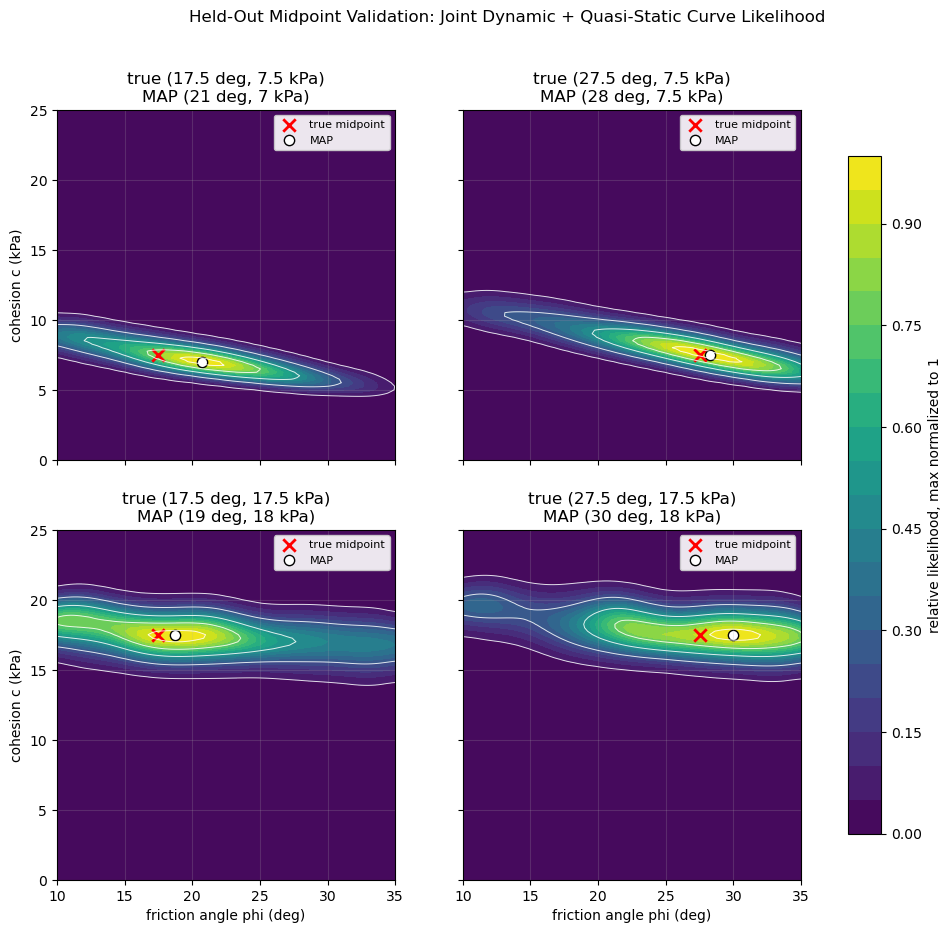

Saved: /Users/daweixu/Desktop/Git_Repository/project_MPM_robot_soil/data/synthetic_data/gp_piecewise_curve_split/midpoint_validation_likelihood_maps.png


In [11]:
if val_feature_rows:
    fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
    axes = axes.ravel()

    for ax, row, result in zip(axes, val_feature_rows, validation_results):
        phi_grid, c_grid, LL, best = make_likelihood_grid(row, obs_noise_std=0.12)
        RL = relative_likelihood(LL)
        im = ax.contourf(phi_grid, c_grid, RL, levels=np.linspace(0, 1, 21), cmap="viridis")
        ax.contour(phi_grid, c_grid, RL, levels=[0.05, 0.25, 0.5, 0.75, 0.95], colors="white", linewidths=0.7, alpha=0.85)
        ax.scatter(row["phi_deg"], row["cohesion_kPa"], c="red", marker="x", s=80, linewidths=2, label="true midpoint")
        ax.scatter(best["phi_deg"], best["cohesion_kPa"], c="white", edgecolors="black", marker="o", s=55, label="MAP")
        ax.set_title(
            f"true ({row['phi_deg']:g} deg, {row['cohesion_kPa']:g} kPa)\n"
            f"MAP ({best['phi_deg']:.2g} deg, {best['cohesion_kPa']:.2g} kPa)"
        )
        ax.grid(True, alpha=0.2)
        ax.legend(fontsize=8, loc="upper right", framealpha=0.9)

    for ax in axes[::2]:
        ax.set_ylabel("cohesion c (kPa)")
    for ax in axes[-2:]:
        ax.set_xlabel("friction angle phi (deg)")

    cbar = fig.colorbar(im, ax=axes.tolist(), shrink=0.88)
    cbar.set_label("relative likelihood, max normalized to 1")
    fig.suptitle("Held-Out Midpoint Validation: Joint Dynamic + Quasi-Static Curve Likelihood", y=0.98)
    path = OUT_DIR / "midpoint_validation_likelihood_maps.png"
    plt.savefig(path, dpi=180, bbox_inches="tight")
    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close()
    print(f"Saved: {path}")
else:
    print("No validation rows found; skipping validation likelihood maps.")


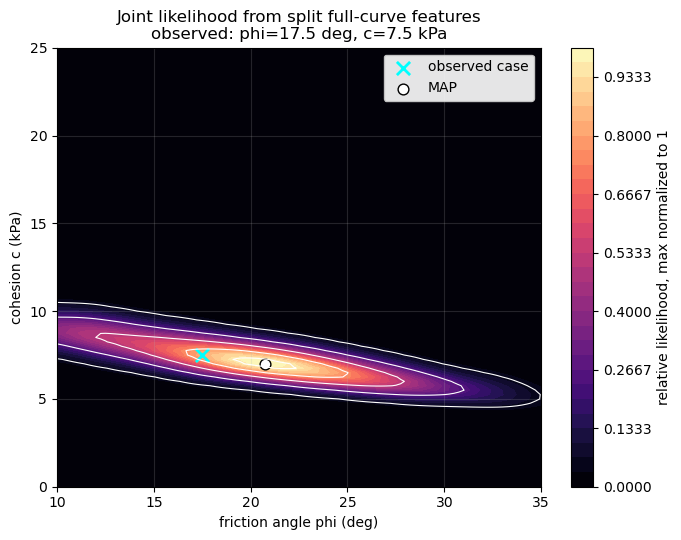

Saved: /Users/daweixu/Desktop/Git_Repository/project_MPM_robot_soil/data/synthetic_data/gp_piecewise_curve_split/demo_split_curve_likelihood_map.png


In [12]:
# Build one demonstration likelihood map from the first validation row if available;
# otherwise use the center-ish training row as an observed curve.
demo_row = val_feature_rows[0] if val_feature_rows else train_feature_rows[len(train_feature_rows)//2]
phi_grid, c_grid, LL, best = make_likelihood_grid(demo_row, obs_noise_std=0.12)
RL = relative_likelihood(LL)

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.contourf(phi_grid, c_grid, RL, levels=np.linspace(0, 1, 31), cmap="magma")
ax.contour(phi_grid, c_grid, RL, levels=[0.05, 0.25, 0.5, 0.75, 0.95], colors="white", linewidths=0.8)
ax.scatter(demo_row["phi_deg"], demo_row["cohesion_kPa"], c="cyan", marker="x", s=90, linewidths=2, label="observed case")
ax.scatter(best["phi_deg"], best["cohesion_kPa"], c="white", edgecolors="black", s=60, label="MAP")
ax.set_xlabel("friction angle phi (deg)")
ax.set_ylabel("cohesion c (kPa)")
ax.set_title(
    "Joint likelihood from split full-curve features\n"
    f"observed: phi={demo_row['phi_deg']:g} deg, c={demo_row['cohesion_kPa']:g} kPa"
)
ax.grid(True, alpha=0.2)
ax.legend(framealpha=0.9)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("relative likelihood, max normalized to 1")
plt.tight_layout()
path = OUT_DIR / "demo_split_curve_likelihood_map.png"
plt.savefig(path, dpi=180, bbox_inches="tight")
if SHOW_FIGURES:
    plt.show()
else:
    plt.close()
print(f"Saved: {path}")


In [13]:
print("Notebook outputs:")
for path in sorted(OUT_DIR.glob("*")):
    print(" ", path)


Notebook outputs:
  /Users/daweixu/Desktop/Git_Repository/project_MPM_robot_soil/data/synthetic_data/gp_piecewise_curve_split/demo_split_curve_likelihood_map.png
  /Users/daweixu/Desktop/Git_Repository/project_MPM_robot_soil/data/synthetic_data/gp_piecewise_curve_split/example_dynamic_quasi_static_split.png
  /Users/daweixu/Desktop/Git_Repository/project_MPM_robot_soil/data/synthetic_data/gp_piecewise_curve_split/midpoint_validation_likelihood_maps.png
  /Users/daweixu/Desktop/Git_Repository/project_MPM_robot_soil/data/synthetic_data/gp_piecewise_curve_split/midpoint_validation_map_estimates.csv
  /Users/daweixu/Desktop/Git_Repository/project_MPM_robot_soil/data/synthetic_data/gp_piecewise_curve_split/piecewise_curve_split_training_table.csv
  /Users/daweixu/Desktop/Git_Repository/project_MPM_robot_soil/data/synthetic_data/gp_piecewise_curve_split/piecewise_curve_split_validation_table.csv
